# FIFA Player Market Value Analysis using Exploratory Data Analysis

This project analyzes player performance and attributes to understand the factors influencing market value. The analysis focuses on identifying patterns, correlations, and key drivers using statistical summaries and visualizations.

## Objective

The objective of this analysis is to identify the key factors affecting player market value using exploratory data analysis techniques, including statistical summaries, correlation analysis, and hypothesis-based reasoning.

In [18]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [19]:
#LOAD DATA
df = pd.read_csv('../datasets/fifa_players.csv')

df.head()

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


The dataset is loaded and previewed to understand its structure and contents.

In [20]:
#BASIC INFO
df.shape

(2800, 16)

In [21]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'club', 'position',
       'overall_rating', 'potential_rating', 'matches_played', 'goals',
       'assists', 'minutes_played', 'market_value_million_eur',
       'contract_years_left', 'injury_prone', 'transfer_risk_level'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 2800 non-null   int64  
 1   player_name               2800 non-null   object 
 2   age                       2800 non-null   int64  
 3   nationality               2800 non-null   object 
 4   club                      2800 non-null   object 
 5   position                  2800 non-null   object 
 6   overall_rating            2800 non-null   int64  
 7   potential_rating          2800 non-null   int64  
 8   matches_played            2800 non-null   int64  
 9   goals                     2800 non-null   int64  
 10  assists                   2800 non-null   int64  
 11  minutes_played            2800 non-null   int64  
 12  market_value_million_eur  2800 non-null   float64
 13  contract_years_left       2800 non-null   int64  
 14  injury_p

The dataset structure, column names, and data types are examined to understand the available features.

In [23]:
#MISSING VALUES
df.isnull().sum()

player_id                   0
player_name                 0
age                         0
nationality                 0
club                        0
position                    0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
injury_prone                0
transfer_risk_level         0
dtype: int64

Missing values are identified to ensure data quality before further analysis.


In [24]:
#DATA CLEANING
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna('Unknown', inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

In [25]:
df.isnull().sum()

player_id                   0
player_name                 0
age                         0
nationality                 0
club                        0
position                    0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
injury_prone                0
transfer_risk_level         0
dtype: int64

Missing values were handled based on data type. Numerical columns were filled using median values to avoid skewness, while categorical columns were filled with 'Unknown' to preserve information.

In [26]:
#STATISTICAL SUMMARY
df.describe()

,player_id,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,27.952500,76.866786,81.563929,27.135714,19.261786,12.015000,2250.101429,90.565500,2.527857
std,808.434702,6.750192,9.921113,9.755799,15.979627,11.567858,7.188459,1295.461829,52.078881,1.699445
min,1.000000,17.000000,60.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.670000,0.000000
25%,700.750000,22.000000,68.000000,73.000000,13.750000,9.000000,6.000000,1131.250000,45.355000,1.000000
50%,1400.500000,28.000000,77.000000,82.000000,27.000000,19.000000,12.000000,2251.000000,89.170000,3.000000
75%,2100.250000,34.000000,85.000000,90.000000,41.000000,30.000000,18.000000,3366.250000,136.682500,4.000000
max,2800.000000,39.000000,94.000000,98.000000,54.000000,39.000000,24.000000,4497.000000,179.960000,5.000000


Statistical summaries provide insights into the distribution, central tendency, and variability of numerical features.

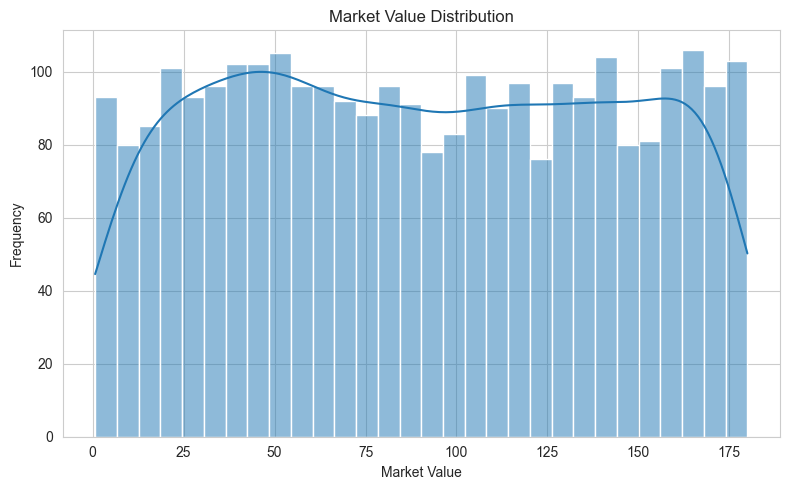

In [27]:
#DISTRIBUTION ANALYSIS
## Market Value Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['market_value_million_eur'], bins=30, kde=True)
plt.title('Market Value Distribution')
plt.xlabel('Market Value')
plt.ylabel('Frequency')
plt.tight_layout()

plt.savefig('../images/distributions/market_value_distribution.png')
plt.show()

The market value distribution is right-skewed, indicating that a small number of players have significantly higher values compared to the majority.

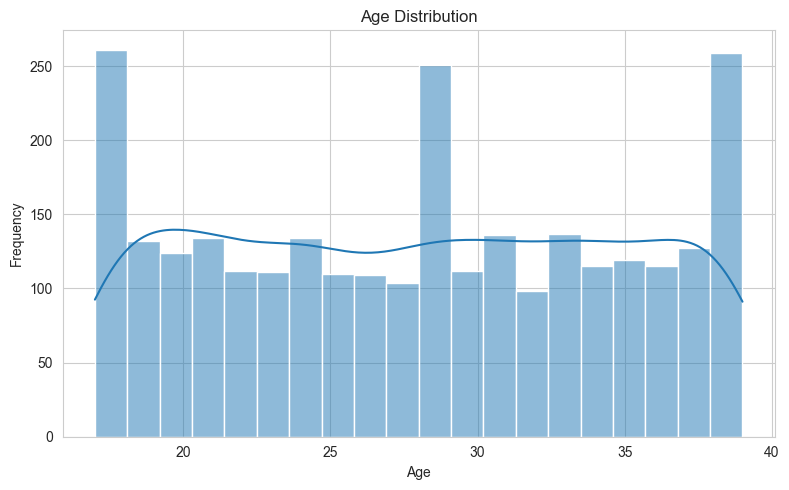

In [28]:
#Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()

plt.savefig('../images/distributions/age_distribution.png')
plt.show()

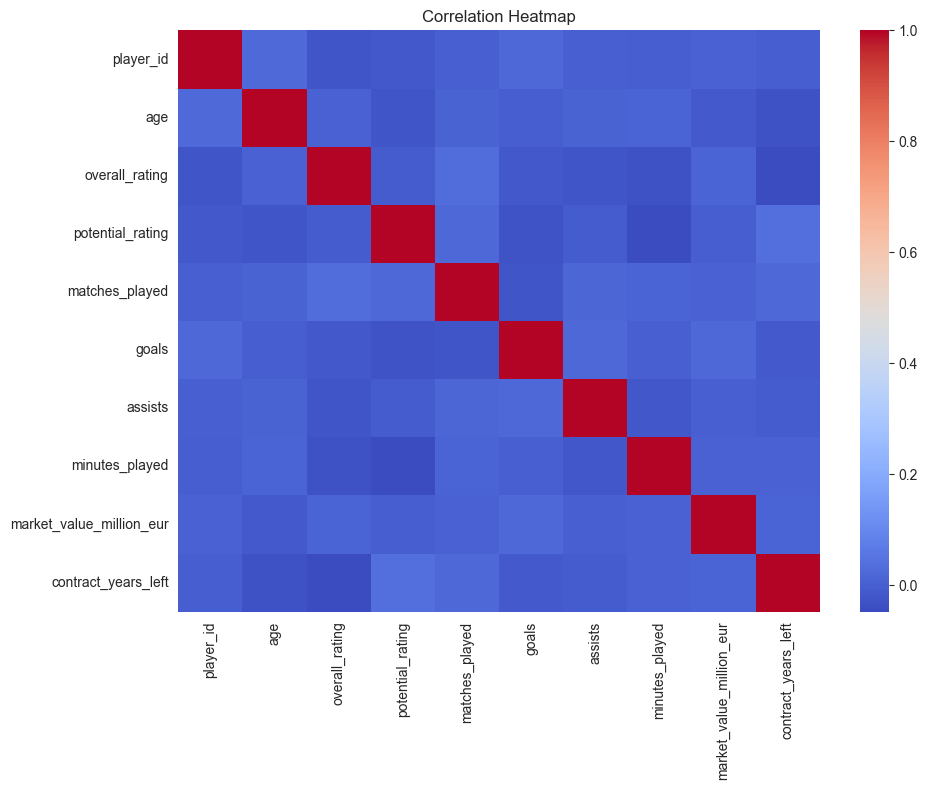

In [29]:
#CORRELATION ANALYSIS
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=False)

plt.title('Correlation Heatmap')
plt.tight_layout()

plt.savefig('../images/correlations/correlation_heatmap.png')
plt.show()

The heatmap shows relationships between variables. Market value appears to have strong positive correlation with overall rating and performance-related features.

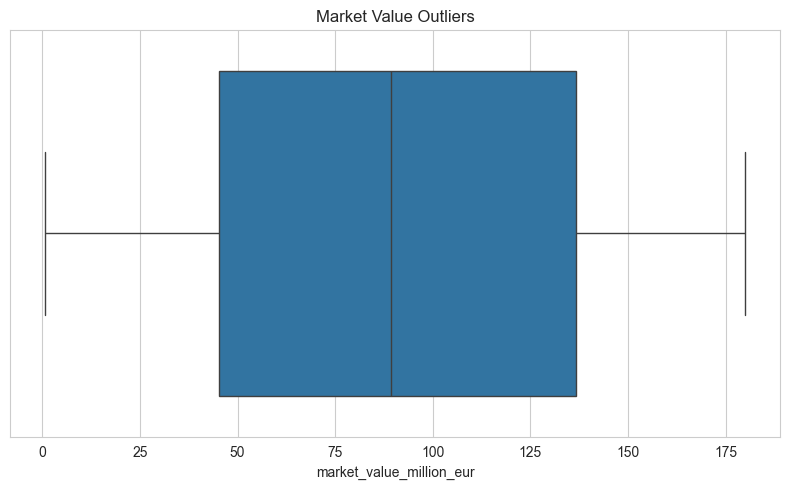

In [30]:
#OUTLIER ANALYSIS
plt.figure(figsize=(8,5))
sns.boxplot(x=df['market_value_million_eur'])
plt.title('Market Value Outliers')

plt.tight_layout()
plt.savefig('../images/outliers/market_value_outliers.png')
plt.show()

The boxplot highlights the presence of outliers, indicating players with unusually high market values.

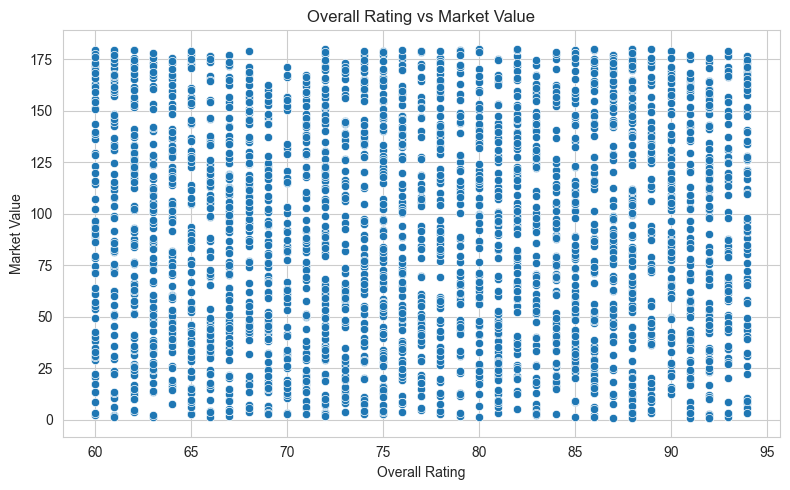

In [31]:
#RELATIONSHIP ANALYSIS
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['overall_rating'], y=df['market_value_million_eur'])

plt.title('Overall Rating vs Market Value')
plt.xlabel('Overall Rating')
plt.ylabel('Market Value')

plt.tight_layout()
plt.savefig('../images/distributions/rating_vs_value.png')
plt.show()

A positive relationship is observed between overall rating and market value, indicating that better-performing players tend to have higher value.

## Hypothesis: Higher-rated players have higher market value

![Overall Rating vs Market Value](../images/distributions/rating_vs_value.png)

*Figure: Relationship between player rating and market value*

The scatter plot shows a clear positive relationship between overall rating and market value. As the rating increases, the market value of players also tends to increase. This supports the hypothesis that higher-rated players have higher market value.

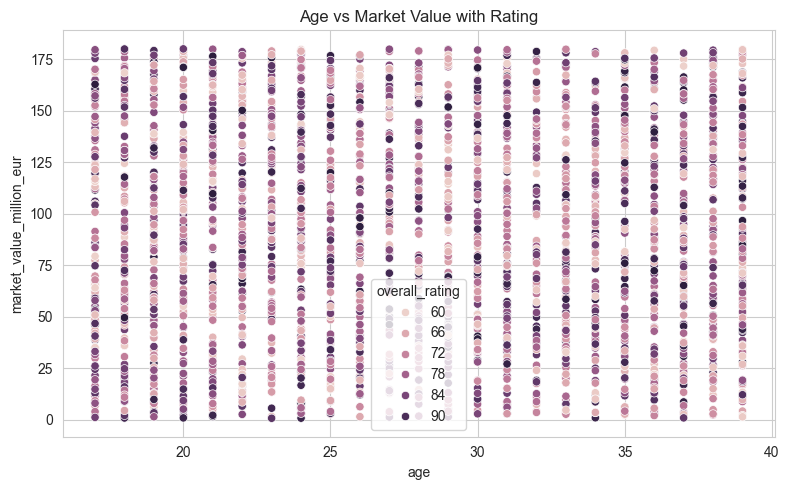

In [35]:
#MULTI-VARIABLE ANALYSIS
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['age'], y=df['market_value_million_eur'], hue=df['overall_rating'])

plt.title('Age vs Market Value with Rating')
plt.tight_layout()
plt.savefig('../images/distributions/multivariable_analysis.png')
plt.show()

Market value is influenced by both age and rating, showing a combined effect of experience and performance.

## FEATURE IMPORTANCE THINKING
Based on the analysis, overall rating appears to be the most influential factor, followed by age and performance metrics.

## Key Insights

- Market value is highly influenced by overall rating  
- The distribution of market value is right-skewed  
- Younger players tend to show higher potential value  
- Strong relationships exist between performance and value  

## Conclusion

The analysis reveals that player market value is primarily driven by overall rating, age, and performance metrics. These insights highlight the importance of both skill level and potential in determining player value.